In [3]:
#Imports functions, packages
from analysis_func import *
import numpy as np

In [4]:
#The following block loads the wavefunction file, sets parameters, etc.

#Loads wavefunction array - Uncomment only the array you want to work with

#Fig. 2
wfn = np.load("symm_ham_excA.npy")

#Fig. 3,4
# wfn = np.load("symm_ham_excA.npy")

#Fig. 6
# wfn = np.load("pert_ham_grdA.npy")

#For reference the indices of all wfn arrays are (time,R1_res,R2_res,state)
print("Wavefunction Array Shape:",np.shape(wfn))
#Reads number of time steps from wfn shape
t_step_max = np.shape(wfn)[0]
print("Number of Time Steps",t_step_max)
#Time step size used in paper
dt=0.1
print("dt =",dt)
#Time array
t = np.linspace(0,t_step_max*dt,t_step_max)
#Sets location of R_1=0 based on resolution of wfn array
axisIndex=int(np.shape(wfn)[1]/2)
print("Grid Location of R1=0:",axisIndex)
#Calculates adiabatic state populations used in figures
adi_pop = np.array([np.sum(np.conjugate(wfn[i,:,:,:])*wfn[i,:,:,:],axis=(0,1)) for i in range(int(1200))])
#Sets adiabatic state for plottin
#Fig 2 - State 0, Fig 3 - State 1, Fig 4 - State 0, Fig 6 - State 0
state=1

Wavefunction Array Shape: (1200, 256, 256, 2)
Number of Time Steps 1200
dt = 0.1
Grid Location of R1=0: 128


Text(0.5, 0.98, 'Reflection Symmetry')

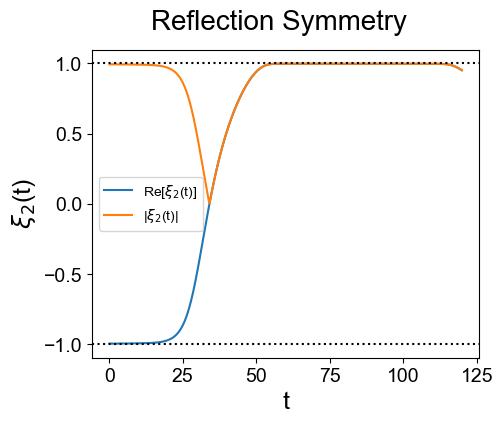

In [5]:
#Plot of Reflection Symmetry (Fig 2d,3d,4d,6d)

S = reflectionExpectationR2WithAxisTimeSeries(wfn)
fig,ax=plt.subplots(figsize=(5,4))
ax.plot(t[1:-1],np.real(S[1:-1]), label=r"Re[$\xi$$_2$(t)]")
ax.plot(t[1:-1],np.abs(S[1:-1]), label=r"|$\xi$$_2$(t)|")
ax.axhline(1, color="k", linestyle="dotted")
ax.axhline(-1, color="k", linestyle="dotted")
ax.legend(loc=6)
ax.set_xlabel("t",fontsize=18)
ax.set_ylabel(r"$\xi$$_2$(t)",fontsize=18)
ax.tick_params(axis='both',labelsize = 14)
plt.suptitle('Reflection Symmetry',fontsize=20)

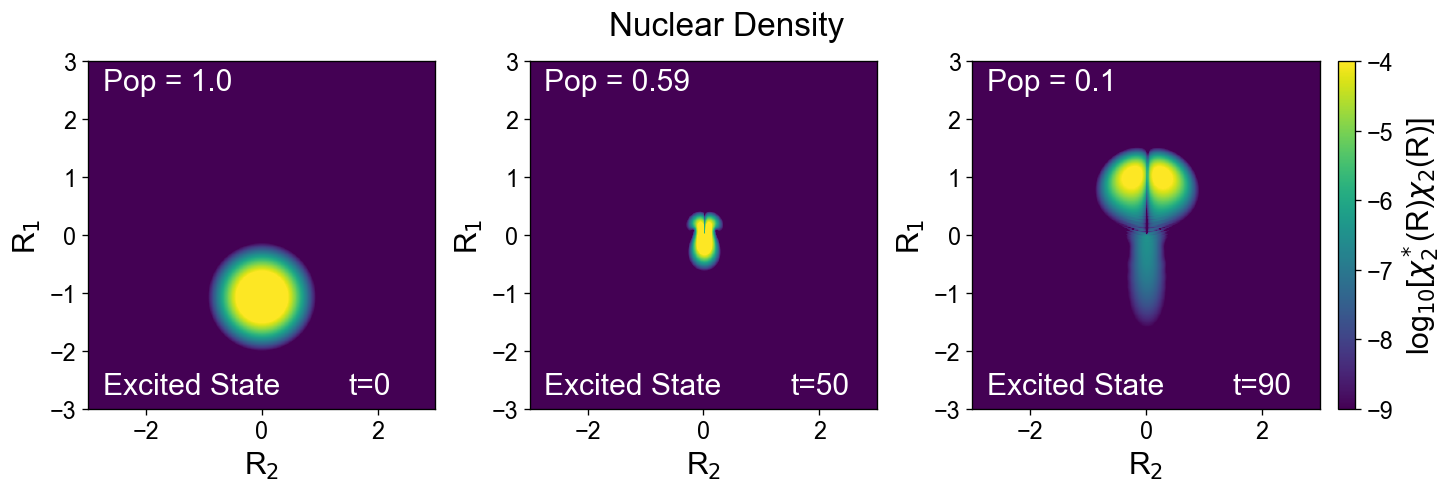

In [6]:
#Sets timesteps at which nuclear density snapshots will be displayed (Same for all Figs)
timesteplist=[0,500,900]
#Plots snapshot of the nuclear density (Fig 2a-c, Fig 3a-c, Fig 4a-c, Fig 6a-c)
plotWfnImage2(adi_pop,wfn,timesteplist,state,log=True)

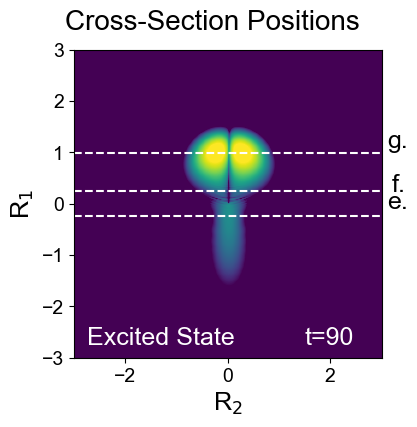

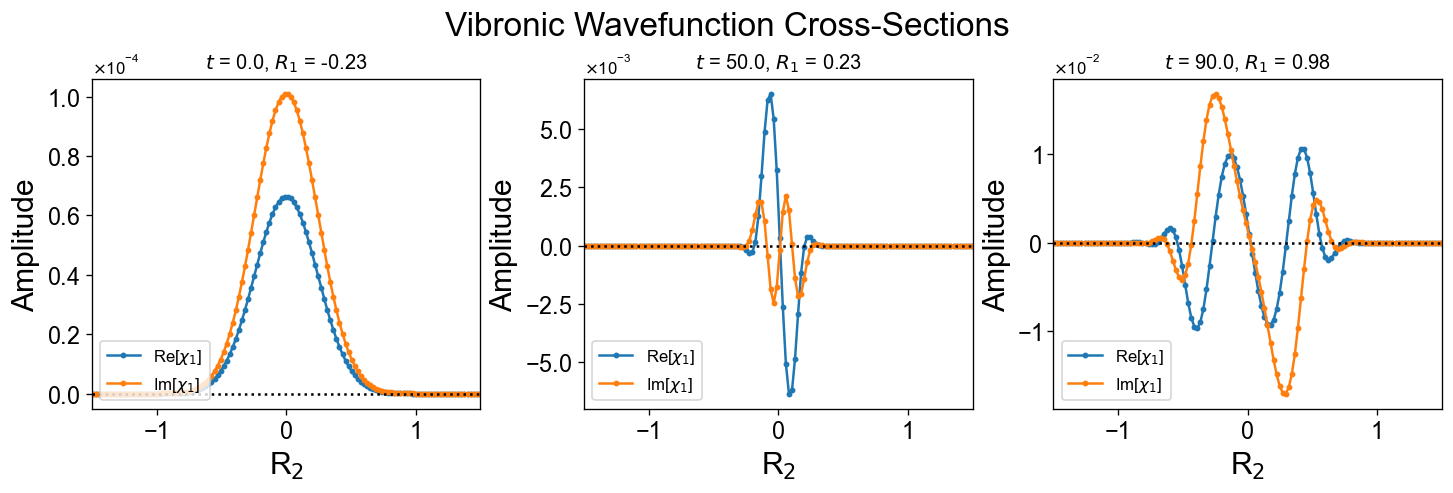

In [8]:
#Sets R2 grid locations at which cross section are taken. Uncomment only the one you want to work with

#Fig 2e-h
# lines=[118,138,175]

#Fig 3e-h
lines=[118,138,170]

#Fig 4e-h
# lines=[118,138,205]

#Fig 6e-h
# lines=[124,138,190]

#Sets timesteps individually for plots (not necessary, change in future)
times=timesteplist[-1]*4

#Shows the location of cross sections to be taken (Fig 2h, Fig 3h, Fig 4h, Fig6h)
plotWfnImage(wfn,timesteplist[-1],lines,state,log=True)

#Show cross sections of nuclear wavefunction (Fig 2e-g, Fig 3e-g, Fig 4e-g, Fig6e-g)
plotCuts(wfn,timesteplist,lines,state)